# 2026-09-26 GNSS / EKF 静止段核查

来源：`bags/hardware_20260926_161859_702449`，时长247.707秒。仅把用户确认的前100秒当作静止。默认时间窗基于MCAP记录时间相对metadata起点；传感器比较与积分使用整数header采样时间。无外部位置真值，漂移不等于绝对定位误差。

原始MCAP已重新校验CRC、全话题计数，并逐字段比较全部11张缓存表。本notebook默认复用该验证记录，随后重算分析和图。要再次做完整原包验证，将下面的`RUN_RAW_VERIFICATION`设为True。

依赖：numpy、pandas、matplotlib、scipy、pyyaml；原包验证另需mcap、mcap-ros2-support。执行notebook另需nbformat、nbclient和ipykernel。

In [1]:
from pathlib import Path
import contextlib, io, json, runpy
import pandas as pd
from IPython.display import Image, display
HERE = Path.cwd()
if not (HERE / "jump_analysis.py").exists():
    HERE = HERE / "agi_ros2/analysis/gnss_ekf_static_20260926"
assert (HERE / "jump_analysis.py").exists()
RUN_RAW_VERIFICATION = False
if RUN_RAW_VERIFICATION:
    runpy.run_path(str(HERE / "verify_source.py"), run_name="__main__")
validation = json.loads((HERE / "source_validation.json").read_text())
assert validation["stored_crcs_checked"] and validation["all_counts_match_metadata"]
print("Original bag verified:", validation["total_messages"], "messages")
display(pd.DataFrame(validation["cached_tables_verified"]).T)

Original bag verified: 531593 messages


,rows,columns,all_values_match
/sensors/navigation,2425,21,True
/sensors/mavlink/status,249,61,True
/parameter_events,15,22,True
/sensors/imu,123682,42,True
/fused_state,123672,54,True
/rosout,36,9,True
/authority,28460,13,True
/health,28459,16,True
/navigation/status,248,3,True
/navigation/origin,246,13,True


In [2]:
for filename in ["gnss_quality.py", "imu_audit.py", "ekf_audit.py", "jump_analysis.py"]:
    with contextlib.redirect_stdout(io.StringIO()):
        runpy.run_path(str(HERE / filename), run_name="__main__")
    print("Recomputed", filename)
jump = json.loads((HERE / "jump_results.json").read_text())
gnss = json.loads((HERE / "gnss_quality.json").read_text())
imu = json.loads((HERE / "imu_results.json").read_text())
ekf = json.loads((HERE / "ekf_audit_metrics.json").read_text())

Recomputed gnss_quality.py


Recomputed imu_audit.py


Recomputed ekf_audit.py


Recomputed jump_analysis.py


## 相同静止时窗的位置比较

EKF约5.798秒才初始化，比较用[6,100)秒两话题各自的全部有效消息。各话题的首末采样时刻相差不超过一个导航周期；不是逐样本误差比较。图用采样时间，统计窗口用记录时间。

,n,receipt_interval_s,span_xyz_m,end_minus_start_xyz_m,max_horizontal_from_first_m,mean_xyz_m
fused,46942,"[6.00031844, 99.99929543]","[1.5043860439206604, 4.9550697933145695, 5.598...","[-1.332688412578486, 4.929661077833408, -5.530...",5.106625,"[-1.078756803285763, 1.346153046042709, -2.150..."
local_navigation,912,"[6.001295880000001, 99.918360324]","[1.1309777780254728, 4.298356609374808, 9.2900...","[-0.8898127732713152, 4.298356609374808, -9.29...",4.389492,"[-0.9514611662132286, 1.1031820691287602, -3.4..."


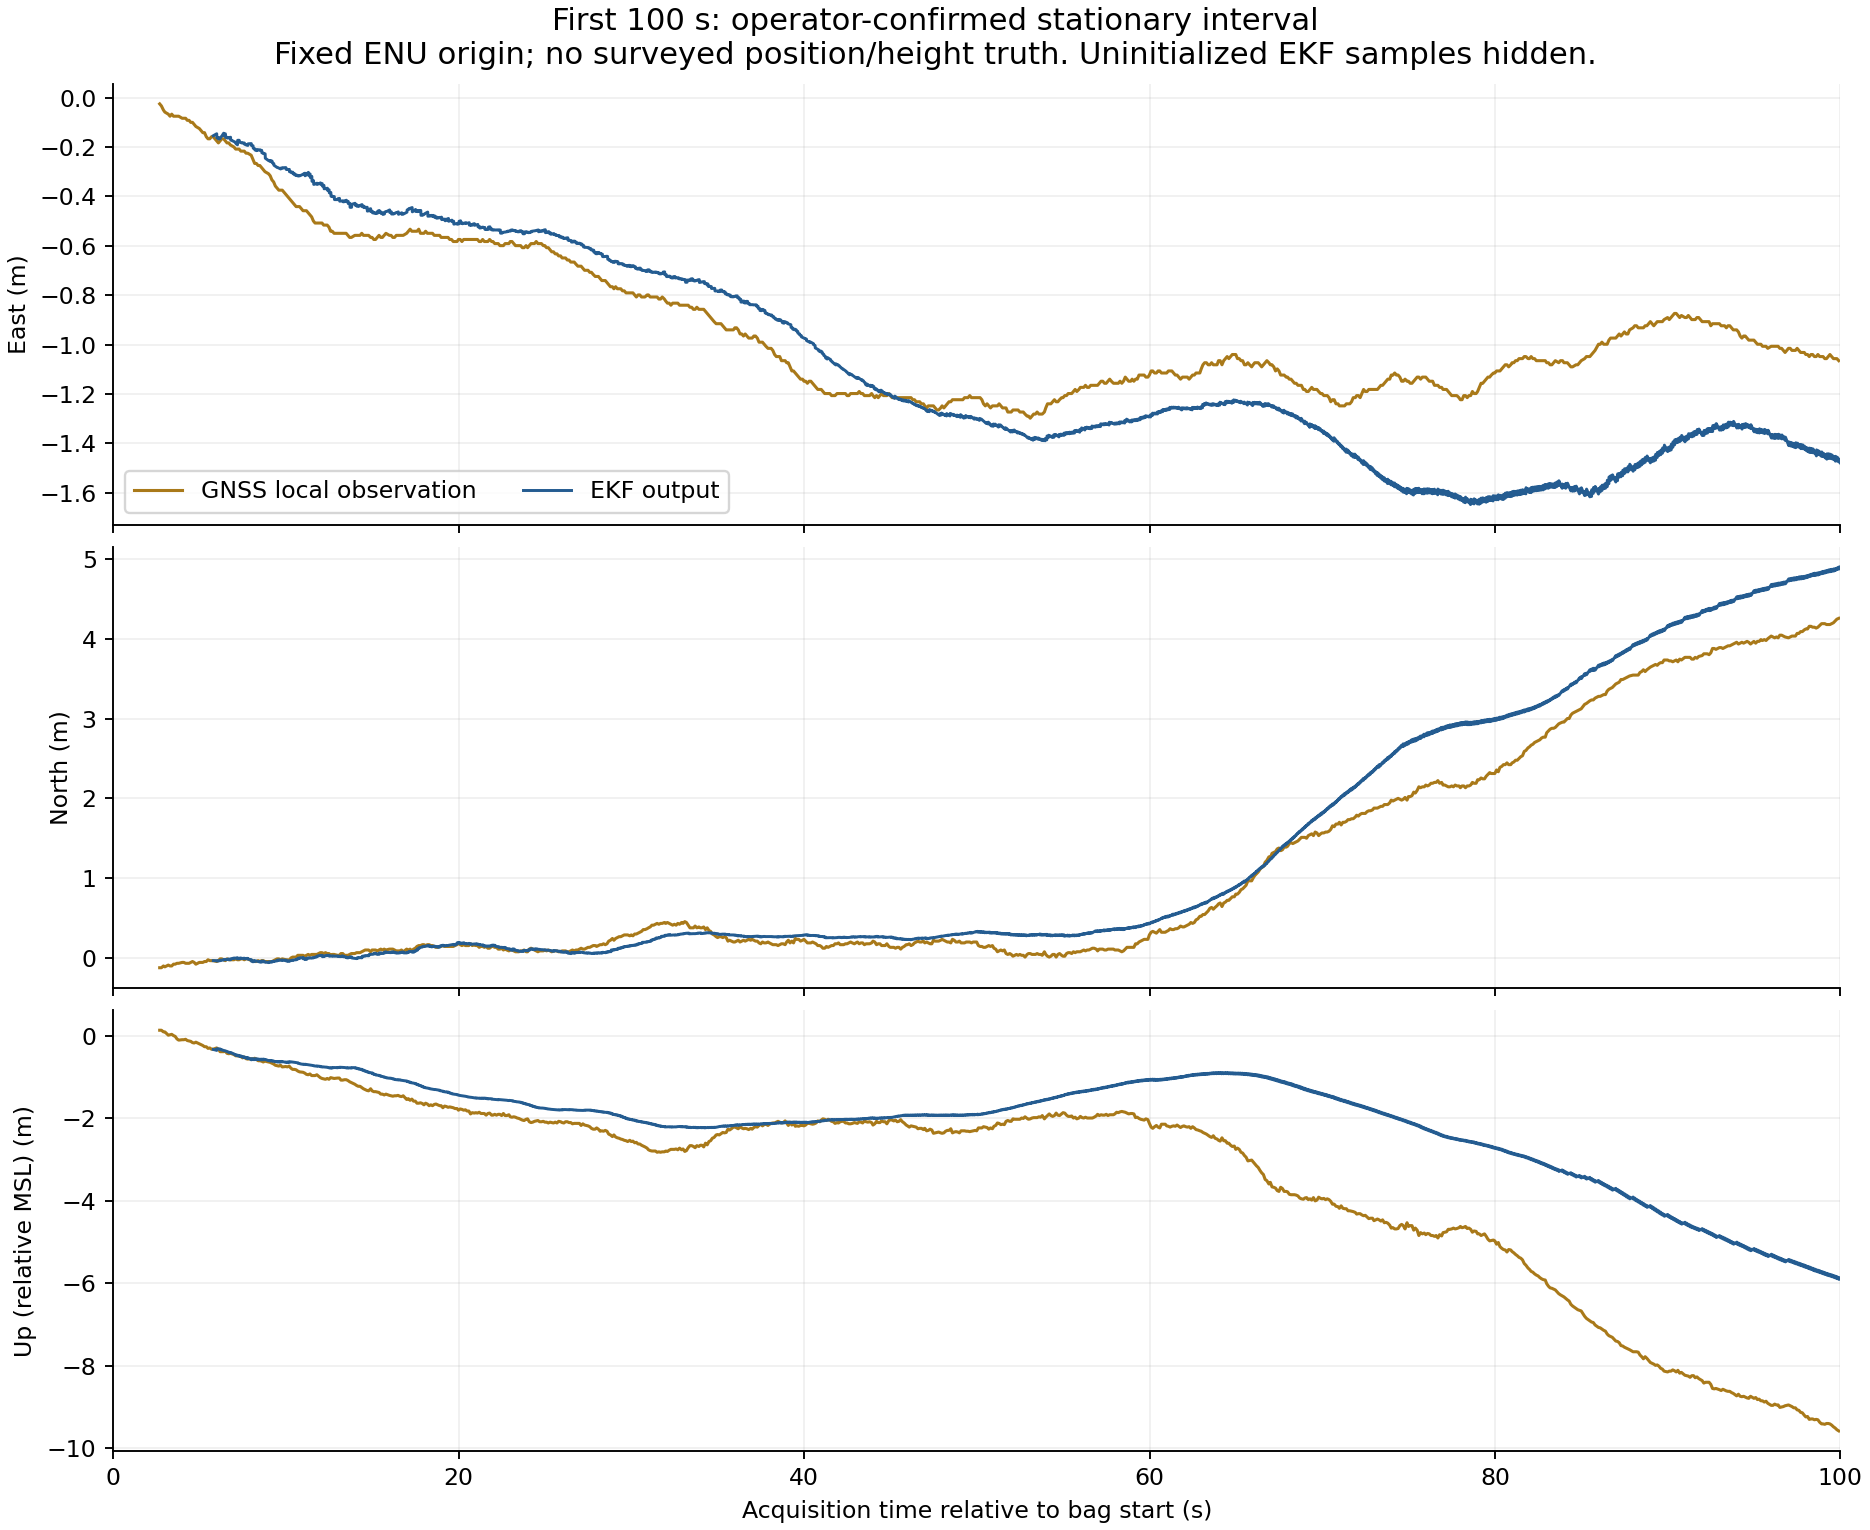

In [3]:
display(pd.DataFrame(jump["common_static_window_6_100"]).T)
display(Image(filename=str(HERE / "static_positions.png")))

## 每次导航更新时的跳变

用rtk_stamp推进识别接受的导航更新，排除初始化、跨reset和异常dt。近似校正量 = 本帧位置 − 上帧位置 − 上帧速度×dt − 0.5×上帧加速度×dt²。它是当前输出时刻的校正代理量，包含迟到观测回溯校正后的再传播效应，不是内部精确的Kalman增量或innovation。非更新帧的同一计算用于检验近似误差。

,n,median,p95,max,min,mean
horizontal_correction_m,912.0,0.012171,0.035153,0.043396,0.000356,0.015820
vertical_correction_abs_m,912.0,0.015849,0.048987,0.052301,0.000076,0.021123
correction_3d_m,912.0,0.020350,0.058668,0.061841,0.001832,0.027178
measurement_age_s,912.0,0.046565,0.097962,0.103925,0.003205,0.049104


,n,median,p95,max,min,mean
horizontal_correction_m,46130.0,2.309927e-07,8.530187e-07,0.000001,4.962024e-10,3.642661e-07
vertical_correction_abs_m,46130.0,3.447876e-07,6.317328e-07,0.000001,8.818013e-12,3.343140e-07
correction_3d_m,46130.0,5.329898e-07,9.978199e-07,0.000002,1.768779e-09,5.162045e-07


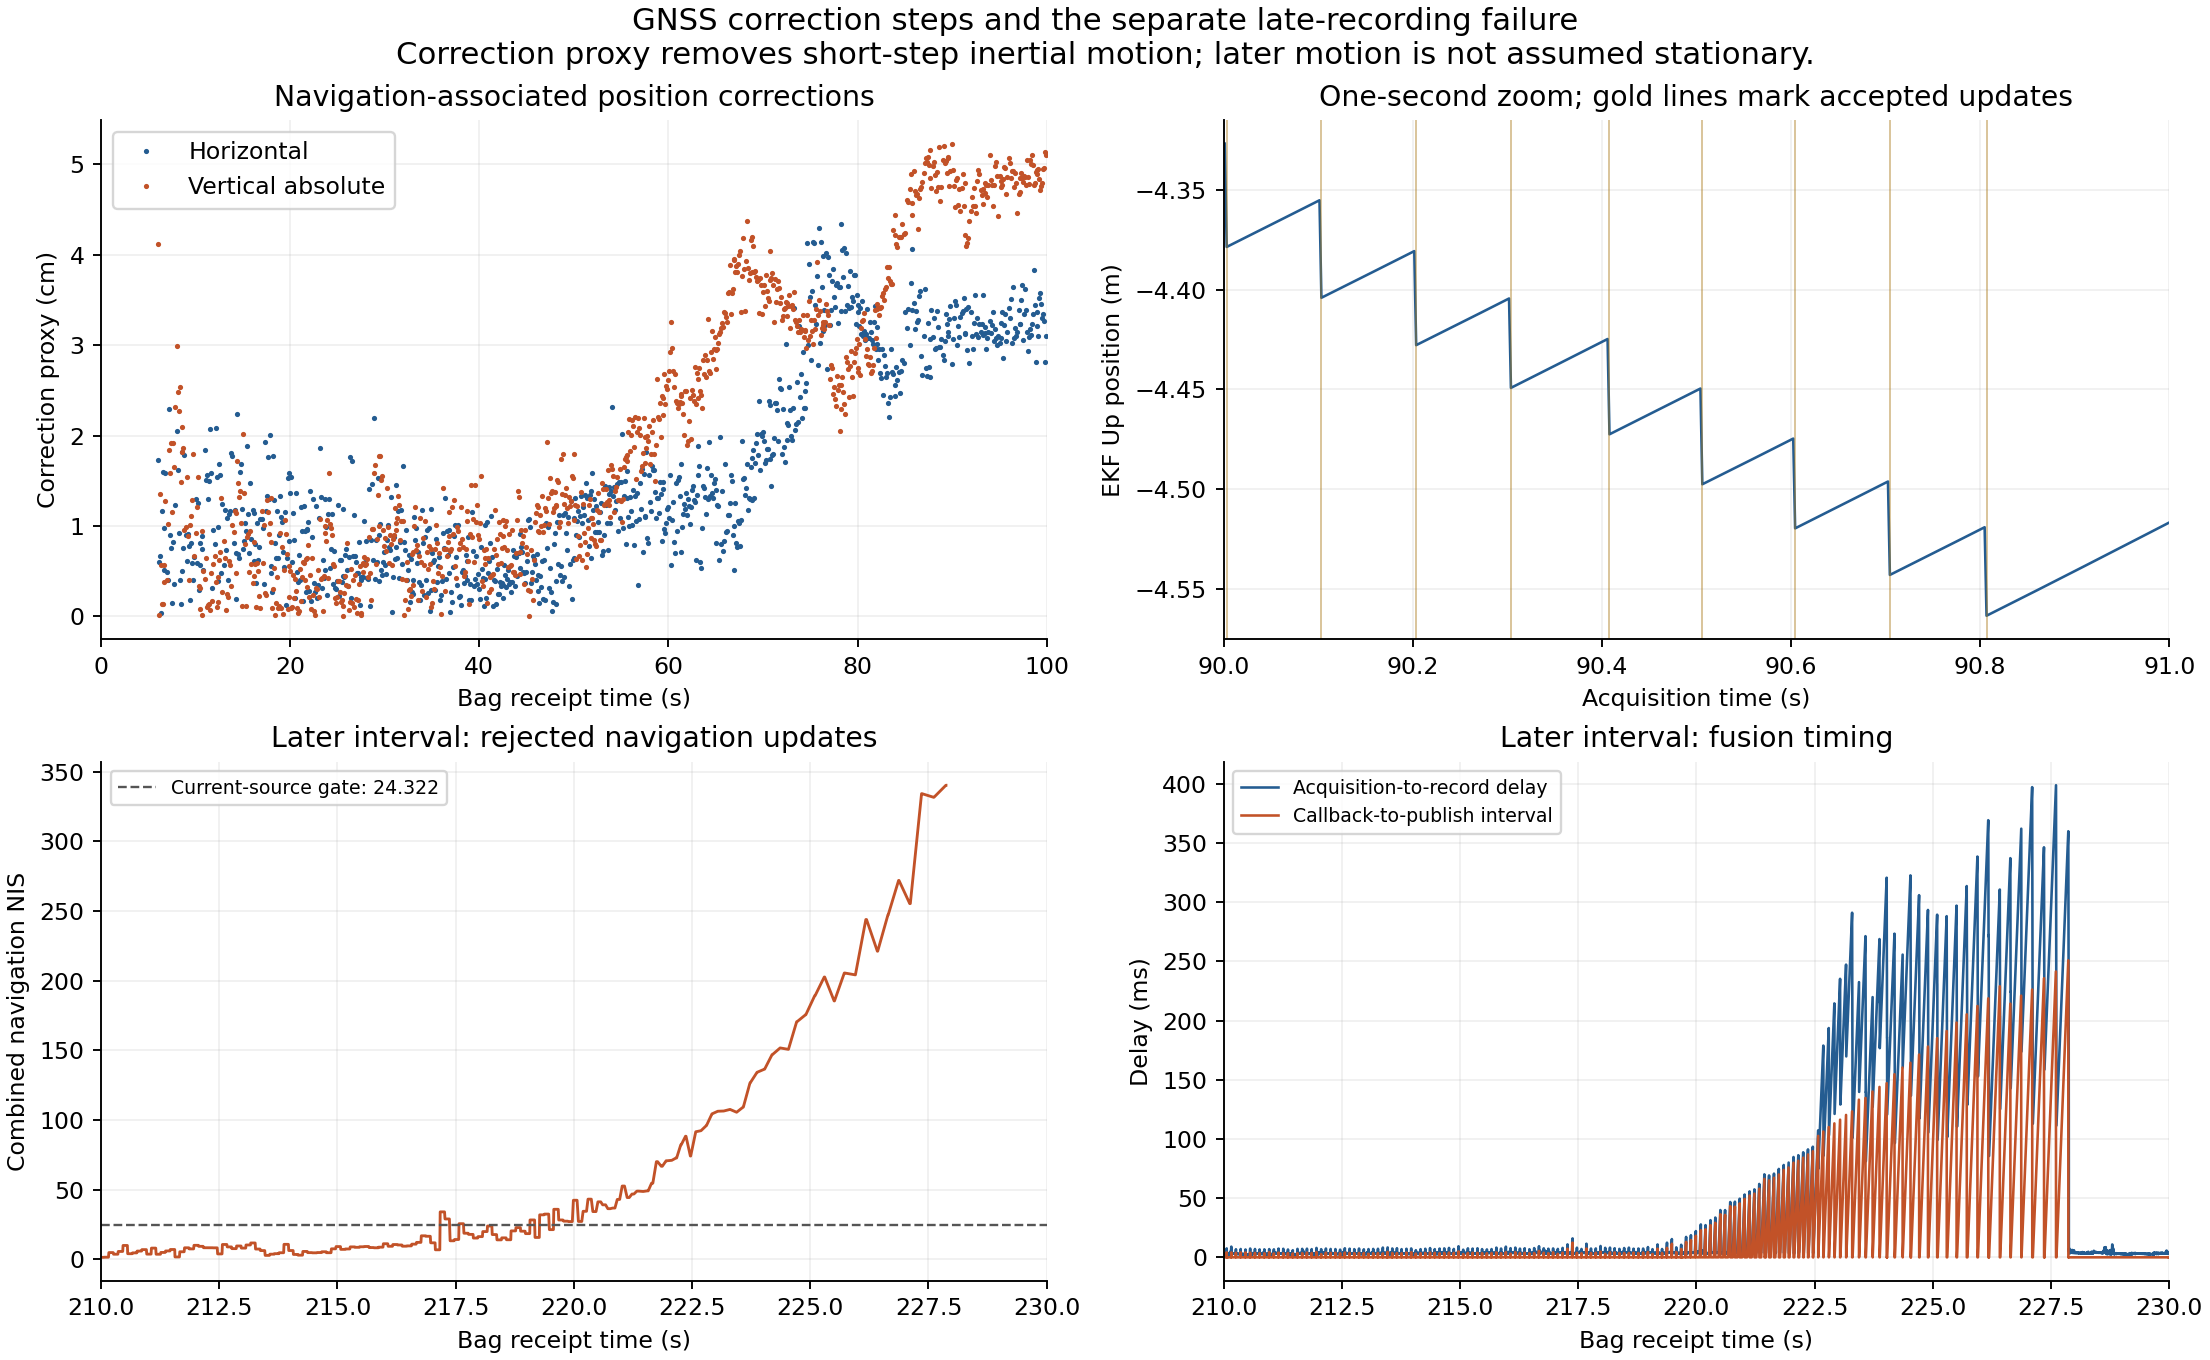

In [4]:
display(pd.DataFrame(jump["windows"]["0_100"]["update"]).T)
display(pd.DataFrame(jump["windows"]["0_100"]["no_update"]).T)
display(Image(filename=str(HERE / "corrections_and_failure.png")))

## 完整核查与限制

- `README.md`：操作优先级和关键结论。
- `gnss_notes.md` / `gnss_quality.json`：GPS漂移、位置/速度一致性、坐标重建。
- `imu_findings.md` / `imu_results.json`：静止IMU、时序和动态航向核查。
- `ekf_audit_notes.md` / `ekf_audit_metrics.json`：后段故障链、当前代码噪声离散化风险。

本包没有完整fusion运行参数或二进制身份。当前源码提供机制解释，不能据此断言录包时使用了当前hardware.yaml的全部参数。没有修改生产代码或在线参数。